In [ ]:
import sys
import mediapipe as mp
import cv2 
import numpy as np
import os
from matplotlib import pyplot as plt
import time


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2. keypoints using MP Holistic

In [2]:
mp_holistic = mp.solutions.holistic
mp_drawing=  mp.solutions.drawing_utils

In [6]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)    
    return image, results

In [7]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION)
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

In [ ]:
def draw_styled_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION
                              ,mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1)
                              ,mp_drawing.DrawingSpec(color=(80, 256,121), thickness=1, circle_radius =1 )
                              )
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    

In [ ]:
cap = cv2.VideoCapture(0)
with mp_holistic.Holistic(min_detection_confidence = 0.5, min_tracking_confidence = 0.5) as holistic:
    while cap.isOpened():
        
        # Read feed
        ret, frame = cap.read()
        
        #Make detections
        image, results = mediapipe_detection(frame, holistic)
        #print(results)
        
        #draw landmarks
        draw_styled_landmarks(image, results)
        
        #show to screen
        cv2.imshow('OpenCv feed', image)
       
        
        #Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    
    


In [15]:

cap.release()
cv2.destroyAllWindows()

In [11]:
draw_landmarks(frame, results)

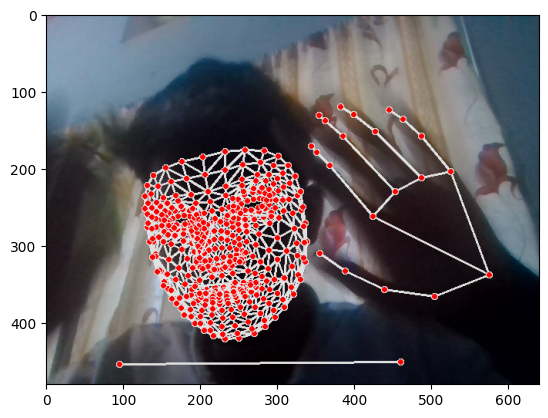

In [13]:
from matplotlib import pyplot as plt


plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))